**Dataset:**<br>https://www.kaggle.com/datasets/juliazubko/25-unlabeled-features-target<br><br>
25 unlabeled features + target.<br>
Mock dataset for regression exercise.<br>-------------

## Contents
1. **Data overview** <br> _Outlook on raw data._
2. **Data wrangling** <br> _Data Cleaning<br>Train/test split<br>Statistical interference<br>Correlations<br>Data preparation and dimentionality reduction._
3. **Machine learning with sklearn** <br> _ML setup<br>Training<br>Performance (training dataset)<br>Test sample performance<br>Best ML model_
4. **Deep-learning with tf.keras** <br> _Training<br>Test sample performance_
5. **Models comparison** <br> _Determination coeff and MeanAbsoluteError are adopted._

## 0. Dependencies

In [1]:
import time

# linear algebra and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistical interference
import scipy.stats
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Preprocessing
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Estimators
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import ElasticNet

# Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Pipelining
from sklearn.pipeline import make_pipeline

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Deep-learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1) Data overview

In [2]:
df = pd.read_csv('/home/petewojtczak/datasets_csv/prediktiv_data.csv')
pd.set_option('display.max_columns', len(df.columns))
df.sample(7)

,id,target,feature01,feature02,feature03,feature04,feature05,feature06,feature07,feature08,feature09,feature10,feature10.1,feature11,feature12,feature13,feature14,feature15,feature16,feature17,feature18,feature19,feature20,feature21,feature22,feature23
1367,1368,79900,0.0,0.0,0,901.0,1088,7,1198,6,7,1920,1,NaN,dog,red,0,NaN,bad,4,1,9,2008,0,110,1998
2738,2739,182000,2.0,528.0,0,1776.0,1560,6,1560,5,5,1962,2,NaN,dog,red,1,okay,bad,3,1,5,2006,0,0,1962
193,194,87000,1.0,200.0,0,765.0,765,4,765,4,7,1925,1,NaN,dog,green,0,NaN,good,2,1,4,2010,0,0,1950
871,872,279500,2.0,523.0,0,1822.0,1828,7,1828,8,5,2002,2,NaN,NaN,red,1,good,good,3,1,6,2009,0,0,2003
1303,1304,112500,1.0,288.0,0,928.0,928,5,928,5,6,1957,1,NaN,NaN,blue,0,NaN,bad,3,1,6,2008,0,0,1957
1984,1985,85000,1.0,252.0,0,570.0,761,6,1141,4,6,1900,1,NaN,NaN,red,0,NaN,bad,3,1,5,2007,0,380,1950
720,721,58500,0.0,0.0,0,624.0,816,5,816,4,3,1910,1,NaN,NaN,red,1,good,bad,2,1,6,2009,0,0,1950


In [3]:
df.shape

(2930, 26)

Let's compse custom info dataframe _features_:

In [4]:
feature_info = {
    'feature': [],
    'dtype': [],
    'unique_val': [],
    'NaN_count': []
    }

for col in df.columns:
    feature_info['feature'].append(col)
    feature_info['dtype'].append(df[col].dtype)
    feature_info['unique_val'].append(len(df[col].unique()))
    feature_info['NaN_count'].append(df[col].isna().sum())
    
features = pd.DataFrame(feature_info)
features.set_index('feature', inplace=True)
features = features.sort_values(by='unique_val', ascending=False)

In [5]:
features

,dtype,unique_val,NaN_count
feature,,,
id,int64,2930,0
feature07,int64,1292,0
feature05,int64,1083,0
feature04,float64,1059,1
target,int64,1032,0
feature22,int64,635,0
feature02,float64,604,1
feature10,int64,118,0
feature23,int64,61,0


# 2) Data wrangling
2.1) Data cleaning<br>
2.2) Train/test split<br>
2.3) Features' statistical significance<br>
2.4) Correlations<br>
2.5) Data Preparation and dimentionality reduction

## 2.1) Data Cleaning

Some features are found to be either sparse (_feature11_, _feature12_) or having redundant role of index (_id_) and are therefore excluded.

In [6]:
# redundant features exclusion
redundant_features = ['id', 'feature11', 'feature12']
df.drop(columns=redundant_features, inplace=True)
features = features[~features.index.isin(redundant_features)]

Two cases of missing values are present in data - either single missing value per feature or overpresence of missing values (_feature15_). In the first case rows are removed, while in case of _feature15_, we create a category 'NA'.  

In [7]:
# missing values
for col in df.columns:
    if (df[col].isnull().sum() == 1):
        df.drop(df.loc[pd.isna(df[col])].index, inplace=True)
df['feature15'] = df['feature15'].fillna('NA')
features = features.drop('NaN_count', axis=1)

Duplicates are dropped as well.

In [8]:
# duplicates removal
print('No. of duplicates excluded:')
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

No. of duplicates excluded:
4


In [9]:
# We will assume numeric features with more than 120 unique_vals to be continous
continous_condition = ((features['dtype'] == 'int64') | (features['dtype'] == 'float64')) & (features['unique_val'] > 120)
features['continous'] = np.where(continous_condition, True, False)
# We will assume numeric features with less than 120 unique_vals to be ordinal
ordinal_condition = ((features['dtype'] == 'int64') | (features['dtype'] == 'float64')) & (features['unique_val'] <= 120)
features['ordinal'] = np.where(ordinal_condition, True, False)
# We will, of course, assume non-numeric features to be nominal
nominal_condition = (features['dtype'] == 'object')
features['nominal'] = np.where(nominal_condition, True, False)

In [10]:
features

,dtype,unique_val,continous,ordinal,nominal
feature,,,,,
feature07,int64,1292,True,False,False
feature05,int64,1083,True,False,False
feature04,float64,1059,True,False,False
target,int64,1032,True,False,False
feature22,int64,635,True,False,False
feature02,float64,604,True,False,False
feature10,int64,118,False,True,False
feature23,int64,61,False,True,False
feature06,int64,14,False,True,False


Issues with insufficient sample representation within the unique values (value_counts) of nominal features needs to be resolved.

In [11]:
df.shape

(2923, 23)

In [12]:
for feature in features[features.nominal].index:
    for index, value in df[feature].value_counts().iteritems():
        if value < 31:
            df = df[df[feature] != index]
            
for feature in features[features.ordinal].index:
    for index, value in df[feature].value_counts().iteritems():
        if value < 2:
            df = df[df[feature] != index]
            
for feature in features[features['continous']==False].index:
    if df[feature].unique().shape[0]==1:
        df = df.drop(feature, axis=1)
        features = features.loc[features.index != feature]
        print('{} has been dropped.'.format(feature))

feature03 has been dropped.


In [13]:
# Our unique_vals are now longer up-to-date.
features = features.drop('unique_val', axis=1)

In [14]:
df.shape

(2881, 22)

## 2.2) Train/test split

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2881 entries, 0 to 2929
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   target       2881 non-null   int64  
 1   feature01    2881 non-null   float64
 2   feature02    2881 non-null   float64
 3   feature04    2881 non-null   float64
 4   feature05    2881 non-null   int64  
 5   feature06    2881 non-null   int64  
 6   feature07    2881 non-null   int64  
 7   feature08    2881 non-null   int64  
 8   feature09    2881 non-null   int64  
 9   feature10    2881 non-null   int64  
 10  feature10.1  2881 non-null   int64  
 11  feature13    2881 non-null   object 
 12  feature14    2881 non-null   int64  
 13  feature15    2881 non-null   object 
 14  feature16    2881 non-null   object 
 15  feature17    2881 non-null   int64  
 16  feature18    2881 non-null   int64  
 17  feature19    2881 non-null   int64  
 18  feature20    2881 non-null   int64  
 19  featur

In [16]:
df.sample(7)

,target,feature01,feature02,feature04,feature05,feature06,feature07,feature08,feature09,feature10,feature10.1,feature13,feature14,feature15,feature16,feature17,feature18,feature19,feature20,feature21,feature22,feature23
2841,83000,0.0,0.0,864.0,964,8,1414,4,4,1922,1,red,1,good,bad,3,1,9,2006,0,0,1950
468,174000,3.0,660.0,1373.0,1555,7,1555,7,5,2007,2,red,1,bad,good,2,1,6,2009,0,0,2007
1191,240000,2.0,624.0,1522.0,1548,9,2614,6,7,1974,2,red,1,bad,bad,4,1,6,2008,1,1066,1997
244,178000,2.0,476.0,741.0,977,7,1732,6,5,1985,2,red,1,bad,good,3,1,6,2010,1,755,1985
2342,202500,2.0,440.0,1208.0,1621,8,1621,7,7,1984,2,red,0,NA,good,3,1,5,2006,0,0,1998
1839,207500,2.0,528.0,1550.0,1550,5,1550,8,5,2006,2,red,0,NA,good,2,1,7,2007,1,0,2007
2287,93900,0.0,0.0,546.0,546,5,1092,4,6,1970,1,red,0,NA,bad,3,1,5,2007,1,546,1970


In [17]:
y = df['target']
X = df.drop('target', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [18]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2304, 21), (2304,), (577, 21), (577,))

## 2.3) Statistical interference

In [19]:
# continous features
for feature in features[features.continous].index:
    if feature=='target':
        continue
    # features found to be insignificant are excluded
    if scipy.stats.pearsonr(y_train, X_train[feature])[1] > 0.05:
        X_train = X_train.drop(feature, axis=1)
        X_test = X_test.drop(feature, axis=1)
        features = features.loc[features.index != feature]

In [20]:
# ordinal features
for feature in features[features.ordinal].index:
    # features found to be insignificant are excluded
    if scipy.stats.spearmanr(y_train, X_train[feature])[1] > 0.05:
        X_train = X_train.drop(feature, axis=1)
        X_test = X_test.drop(feature, axis=1)
        features = features.loc[features.index != feature]

In [21]:
X_train.shape

(2304, 20)

In [22]:
# Some useful data arrangements
df_train = pd.concat([X_train, y_train], axis=1)

In [23]:
# nominal features
for feature in features[features.nominal].index:
    print(feature, X_train[feature].unique())

feature15 ['good' 'amazing' 'bad' 'NA' 'okay' 'horrible']
feature13 ['red' 'blue' 'green']
feature16 ['amazing' 'good' 'bad' 'okay']


In [24]:
# feature15 is significant (pvalue < 0.05)
stats.kruskal(df_train.loc[df_train['feature15']=='horrible', 'target'],
              df_train.loc[df_train['feature15']=='bad', 'target'],
              df_train.loc[df_train['feature15']=='okay', 'target'],
              df_train.loc[df_train['feature15']=='good', 'target'],
              df_train.loc[df_train['feature15']=='amazing', 'target'],
              df_train.loc[df_train['feature15']=='NA', 'target'])

KruskalResult(statistic=717.3074118245183, pvalue=8.889277743193e-153)

In [25]:
# feature13 is significant (pvalue < 0.05)
stats.kruskal(df_train.loc[df_train['feature13']=='red', 'target'],
              df_train.loc[df_train['feature13']=='blue', 'target'],
              df_train.loc[df_train['feature13']=='green', 'target'])

KruskalResult(statistic=185.99516857719308, pvalue=4.08942561662373e-41)

In [26]:
# feature16 is significant (pvalue < 0.05)
stats.kruskal(df_train.loc[df_train['feature16']=='bad', 'target'],
              df_train.loc[df_train['feature16']=='okay', 'target'],
              df_train.loc[df_train['feature16']=='good', 'target'],
              df_train.loc[df_train['feature16']=='amazing', 'target'])

KruskalResult(statistic=1040.9391220764276, pvalue=2.3659795366654337e-225)

## 2.4) Correlations

In [27]:
# some data manitulation that might be useful
row_to_move = features.loc['target']
features = features.drop('target')
features = pd.concat([row_to_move.to_frame().T, features])
features.loc['target','ordinal']=True
features.loc['target','nominal']=True

### Continous features.

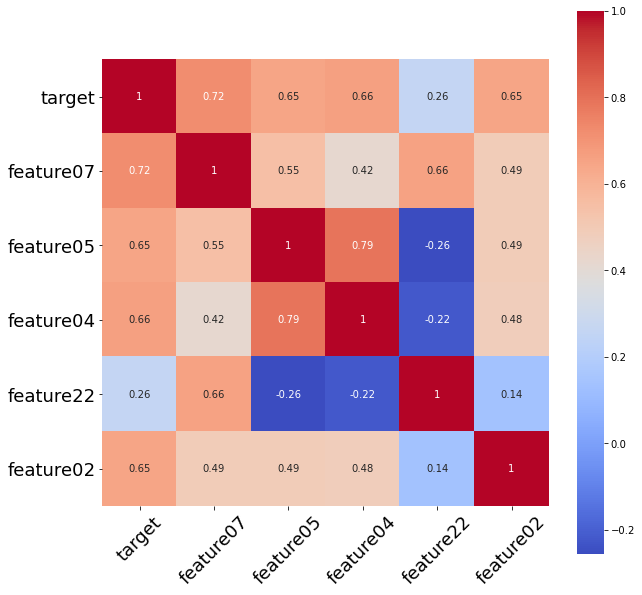

In [28]:
# Pearson coeff heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(df_train[features[features.continous].index].corr(), annot=True, square=True, cmap='coolwarm')
plt.tick_params(axis='x', labelsize=18, rotation=45)
plt.tick_params(axis='y', labelsize=18, rotation=0)
plt.show()

Colinearity is present in our dataset.

### Ordinal features.

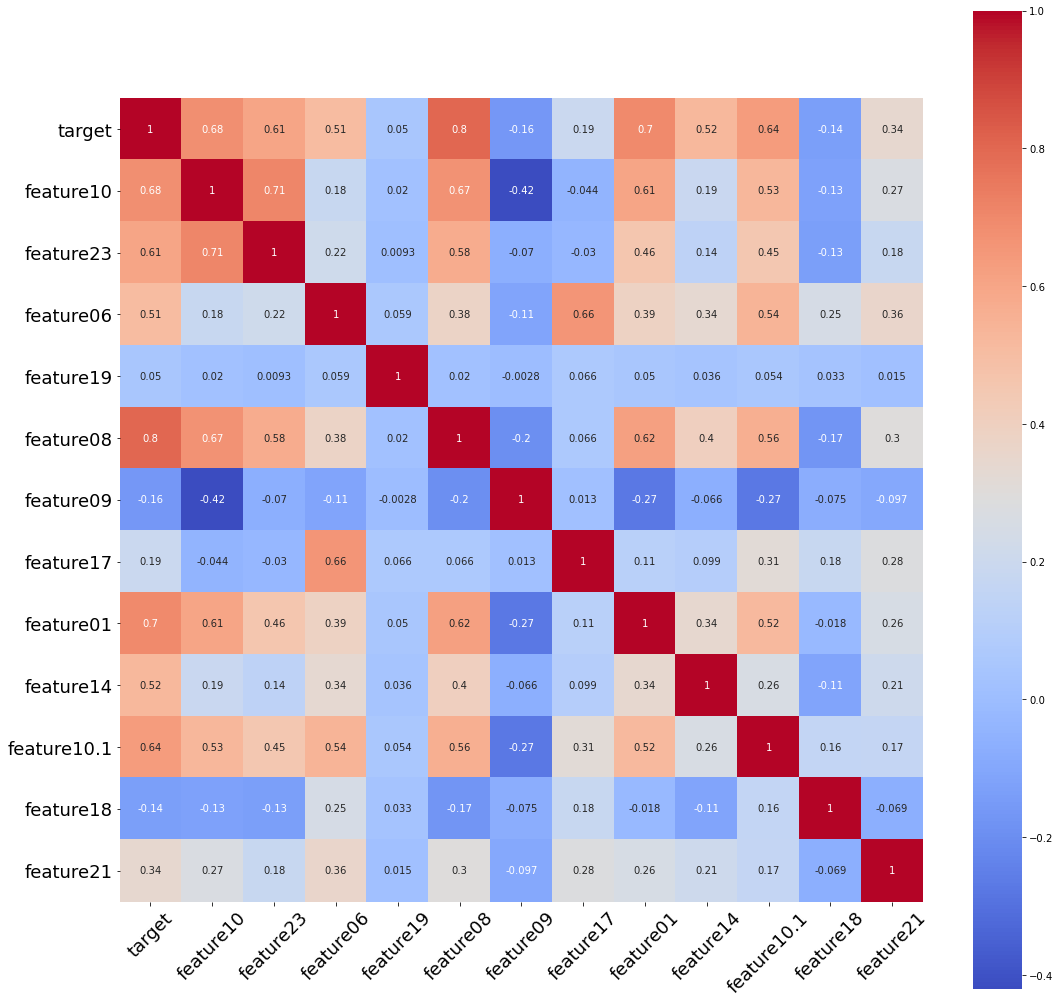

In [29]:
# Spearman coeff heatmap
plt.figure(figsize=(18, 18))
sns.heatmap(df_train[features[features.ordinal].index].corr(method='spearman'), annot=True, square=True, cmap='coolwarm')
plt.tick_params(axis='x', labelsize=18, rotation=45)
plt.tick_params(axis='y', labelsize=18, rotation=0)
plt.show()

We might want to reconsider _feature19_. However, based on the printed p-value below, we can confidently assert its significance.

In [30]:
scipy.stats.spearmanr(y_train, X_train['feature19'])[1]

0.016961301754902267

### Nominal features.

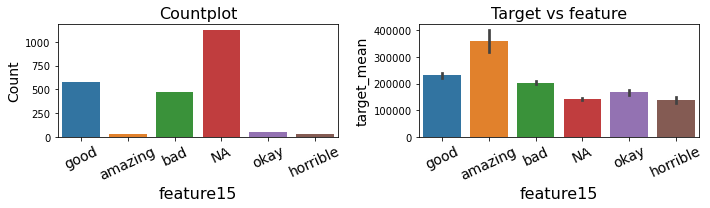

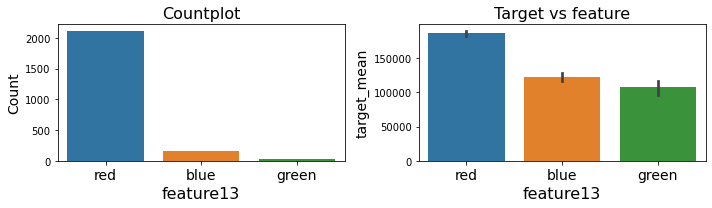

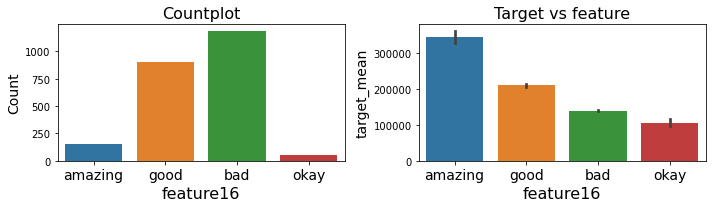

In [31]:
for feature in features[features.nominal].index:
    if feature=='target':
        continue
        
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    
    sns.countplot(data=df_train, x=feature, ax=axes[0])
    axes[0].set_title('Countplot', fontsize=16)
    if feature=='feature15':
        axes[0].tick_params(axis='x', labelsize=14, rotation=25)
    else:
        axes[0].tick_params(axis='x', labelsize=14)
    axes[0].tick_params(axis='y', labelsize=10)
    axes[0].set_xlabel(xlabel=feature, fontsize=16)
    axes[0].set_ylabel(ylabel='Count', fontsize=14)
    
    sns.barplot(data=df_train, x=feature, y=df_train.target, ax=axes[1])
    axes[1].set_title('Target vs feature', fontsize=16)
    if feature=='feature15':
        axes[1].tick_params(axis='x', labelsize=14, rotation=25)
    else:
        axes[1].tick_params(axis='x', labelsize=14)
    axes[1].tick_params(axis='y', labelsize=10)
    axes[1].set_xlabel(xlabel=feature, fontsize=16)
    axes[1].set_ylabel(ylabel='target_mean', fontsize=14)
    
    plt.tight_layout()
    plt.show()

## 2.5) Data preparation and dimentionality reduction

In [32]:
features = features.loc[features.index != 'target']
features.sort_index(inplace=True)

Due to collinearity among the features and the necessity of employing dummy variables, PCA will be applied. The following data preparation scheme will be conducted for this dataset: Z-score normalization for continuous features, MinMaxScaler for categorical features, and dummy variables for nominal features. We are interested in the number of principal components that retain at least 95% of the original variability. We will now apply PCA to our training data to determine the desired number of components, as this parameter needs to be specified downstream in our pipelines.

In [33]:
prep = make_column_transformer((StandardScaler(), features[features.continous].index), 
                               (MinMaxScaler(), features[features.ordinal].index),
                               (OneHotEncoder(drop='first'), features[features.nominal].index))

df_transformed = prep.fit_transform(X_train)

pca = PCA(n_components=15, svd_solver='full')
pca.fit(df_transformed)

explained_variance_ratio = 0
components=0
while explained_variance_ratio<0.95:
    explained_variance_ratio += pca.explained_variance_ratio_[components]
    components += 1
print('Suggested number of principal components: {}'.format(components + 1))

Suggested number of principal components: 10


### Training data summarization

In [34]:
X_train.columns

Index(['feature01', 'feature02', 'feature04', 'feature05', 'feature06',
       'feature07', 'feature08', 'feature09', 'feature10', 'feature10.1',
       'feature13', 'feature14', 'feature15', 'feature16', 'feature17',
       'feature18', 'feature19', 'feature21', 'feature22', 'feature23'],
      dtype='object')

In [35]:
features.index

Index(['feature01', 'feature02', 'feature04', 'feature05', 'feature06',
       'feature07', 'feature08', 'feature09', 'feature10', 'feature10.1',
       'feature13', 'feature14', 'feature15', 'feature16', 'feature17',
       'feature18', 'feature19', 'feature21', 'feature22', 'feature23'],
      dtype='object')

In [36]:
features.head(3)

,dtype,continous,ordinal,nominal
feature01,float64,False,True,False
feature02,float64,True,False,False
feature04,float64,True,False,False


In [37]:
X_train.shape, y_train.shape

((2304, 20), (2304,))

# 3) Machine learning with sklearn

## 3.1) ML setup

In [38]:
# pipelining data preparation and dimentionality reduction - see section 2.5 for some details
prep = make_column_transformer((StandardScaler(), features[features.continous].index), 
                               (MinMaxScaler(), features[features.ordinal].index),
                               (OneHotEncoder(drop='first'), features[features.nominal].index))
pipelines = {
    'linreg':make_pipeline(prep, PCA(n_components=10, svd_solver='full'), LinearRegression()),
    'gbr':make_pipeline(prep, PCA(n_components=10, svd_solver='full'), GradientBoostingRegressor(random_state=0)),
    'sgd':make_pipeline(prep, PCA(n_components=10, svd_solver='full'), SGDRegressor(random_state=0)),
    'enet':make_pipeline(prep, PCA(n_components=10, svd_solver='full'), ElasticNet(random_state=0))
    }

In [39]:
# regressors' parameter hyperpace to be searched
hypergrid = {
    'linreg': {
        'linearregression__fit_intercept':[True, False]
    },
    'gbr': {
        'gradientboostingregressor__learning_rate':[0.001, 0.01, 0.1, 0.2, 0.5],
        'gradientboostingregressor__warm_start':[True, False]
        
    },
    'sgd': {
        'sgdregressor__alpha':[0.0001, 0.001, 0.01],
        'sgdregressor__warm_start':[True, False]
    },
    'enet': {
        'elasticnet__alpha':[33, 66, 100, 133, 166],
        'elasticnet__warm_start':[True, False],
        'elasticnet__l1_ratio':[0.001, 0.1, 0.2, 0.5, 0.66, 0.83, 0.999]
    },
    }

## 3.2) Training

In [40]:
%%time
models_r2 = {}
models_mae = {}
for algo, pipeline in pipelines.items():
    model_r2 = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='r2')
    model_mae = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='neg_mean_absolute_error')
    model_r2.fit(X_train,y_train)
    model_mae.fit(X_train,y_train)
    models_r2[algo] = model_r2
    models_mae[algo] = model_mae

CPU times: user 7min 29s, sys: 4.47 s, total: 7min 34s
Wall time: 2min 5s


## 3.3) Performance (training dataset)

In [41]:
train_results = {
    'R2': {algo: round(model.best_score_, 3) for algo, model in models_r2.items()},
    'MAE': {algo: abs(round(model.best_score_, 3)) for algo, model in models_mae.items()}
}

print('\ntarget_min: {}, target_mean: {}, target_max: {}, target_std: {}'.format(y_train.describe()[3],
                                                                               round(y_train.describe()[1], 2),
                                                                               y_train.describe()[-1],
                                                                               round(y_train.describe()[2], 2)))
train_results = pd.DataFrame(train_results)
train_results.sort_values(by='R2', ascending=False)


target_min: 12789.0, target_mean: 180542.69, target_max: 755000.0, target_std: 79801.88


,R2,MAE
gbr,0.853,19707.881
linreg,0.800,24268.509
sgd,0.799,24151.182
enet,0.796,23977.816


## 3.4) Test sample performance

In [42]:
X_test.shape, y_test.shape

((577, 20), (577,))

In [43]:
r2_test_results = {}
mae_test_results = {}

for algo in models_r2.keys():
    y_pred_r2 = models_r2[algo].predict(X_test)
    y_pred_mae = models_mae[algo].predict(X_test)
    r2_test_results[algo] = round(r2_score(y_test, y_pred_r2), 3)
    mae_test_results[algo] = abs(round(mean_absolute_error(y_test, y_pred_mae), 3))

test_results = pd.DataFrame({
    'R2': pd.Series(r2_test_results),
    'MAE': pd.Series(mae_test_results)
})

print('\ntarget_min: {}, target_mean: {}, target_max: {}, target_std: {}'.format(y_test.describe()[3],
                                                                               round(y_test.describe()[1], 2),
                                                                               y_train.describe()[-1],
                                                                               round(y_test.describe()[2], 2)))
test_results.sort_values(by='R2', ascending=False)


target_min: 13100.0, target_mean: 182481.74, target_max: 755000.0, target_std: 74986.91


,R2,MAE
gbr,0.888,18302.058
linreg,0.813,24442.890
sgd,0.813,24316.472
enet,0.809,24157.043


## 3.5) Best ML model

In [44]:
models_r2['gbr'].best_params_

{'gradientboostingregressor__learning_rate': 0.1,
 'gradientboostingregressor__warm_start': True}

In [45]:
models_r2['gbr']

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('standardscaler',
                                                                         StandardScaler(),
                                                                         Index(['feature02', 'feature04', 'feature05', 'feature07', 'feature22'], dtype='object')),
                                                                        ('minmaxscaler',
                                                                         MinMaxScaler(),
                                                                         Index(['feature01', 'feature06', 'feature08', 'feature09', 'feature10',
       'feature10.1', 'feature14', 'feature...
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['feature13', 'feature15', 'feature16'], dtype='object'))])),
                                       ('pca',
                                        PCA(n_components=10,
                                            svd_solver='full')),
                                       ('gradientboostingregressor',
                                        GradientBoostingRegressor(random_state=0))]),
             param_grid={'gradientboostingregressor__learning_rate': [0.001,
                                                                      0.01, 0.1,
                                                                      0.2,
                                                                      0.5],
                         'gradientboostingregressor__warm_start': [True,
                                                                   False]},
             scoring='r2')

# 4) Deep-learning with tf.keras

In [46]:
X_train.shape, y_train.shape

((2304, 20), (2304,))

### Data preparation

In [47]:
# we will rephrase data preparation scheme for clarity
prep = make_column_transformer((StandardScaler(), features[features.continous].index), 
                               (MinMaxScaler(), features[features.ordinal].index),
                               (OneHotEncoder(drop='first'), features[features.nominal].index))

data_pipe = make_pipeline(prep, PCA(n_components=10, svd_solver='full'))
X_train_transformed = data_pipe.fit_transform(X_train)

In [48]:
X_train_transformed.shape

(2304, 10)

### Network architecture

In [49]:
# neural network architecture definition
model = Sequential([
    tf.keras.layers.Dense(64, input_shape=(10,), activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1) 
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                704       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,817
Trainable params: 2,817
Non-trainable params: 0
_________________________________________________________________


## 4.1) Training

In [50]:
# compilation
model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error', metrics=['mae'])

# callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.35, patience=20, min_lr=0.0000005)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# backpropagation
training = model.fit(x=X_train_transformed, y=y_train, validation_split=0.1, batch_size=64, epochs=5000, shuffle=True, verbose=0, callbacks=[early_stopping, reduce_lr, checkpoint])

# training performance
train_mae = training.history['mae']
val_mae = training.history['val_mae']
print(f"Final training MAE: {train_mae[-1]}")
print(f"Final validation MAE: {val_mae[-1]}")

Final training MAE: 19861.193359375
Final validation MAE: 22458.56640625


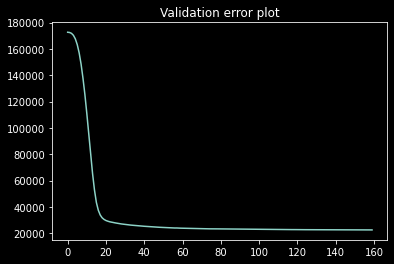

In [51]:
plt.style.use('dark_background') 
plt.plot(val_mae)
plt.title('Validation error plot')
plt.grid(False) 
plt.show()

## 4.2) Test sample performance

In [52]:
X_test.shape, y_test.shape

((577, 20), (577,))

In [53]:
y_pred = model.predict(data_pipe.fit_transform(X_test), verbose=0)
y_pred.shape

(577, 1)

In [54]:
test_results.loc['NeuralNet', 'R2'] = round(r2_score(y_test, y_pred), 3)
test_results.loc['NeuralNet', 'MAE'] = abs(round(mean_absolute_error(y_test, y_pred), 3))

# 5) Models comparison

In [55]:
print('\ntarget_min: {}, target_mean: {}, target_max: {}, target_std: {}'.format(y_test.describe()[3],
                                                                               round(y_test.describe()[1], 2),
                                                                               y_train.describe()[-1],
                                                                               round(y_test.describe()[2], 2)))
test_results.sort_values(by='R2', ascending=False)


target_min: 13100.0, target_mean: 182481.74, target_max: 755000.0, target_std: 74986.91


,R2,MAE
gbr,0.888,18302.058
linreg,0.813,24442.890
sgd,0.813,24316.472
enet,0.809,24157.043
NeuralNet,0.738,27822.731
